<a href="https://www.kaggle.com/code/martinsertin/covid19-global-forecating?scriptVersionId=296953362" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')


SEED = 42
np.random.seed(SEED)

In [2]:

train = pd.read_csv("/kaggle/input/covid19-global-forecasting-week-4/train.csv")
test  = pd.read_csv("/kaggle/input/covid19-global-forecasting-week-4/test.csv")


In [3]:
train.head()

,Id,Province_State,Country_Region,Date,ConfirmedCases,Fatalities
0,1,NaN,Afghanistan,2020-01-22,0.0,0.0
1,2,NaN,Afghanistan,2020-01-23,0.0,0.0
2,3,NaN,Afghanistan,2020-01-24,0.0,0.0
3,4,NaN,Afghanistan,2020-01-25,0.0,0.0
4,5,NaN,Afghanistan,2020-01-26,0.0,0.0


In [4]:
train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])

In [5]:
def make_region(df):
    return df['Country_Region'] + '_' + df['Province_State'].fillna('NA')


train['Region'] = make_region(train)
test['Region'] = make_region(test)


train = train.sort_values(['Region', 'Date'])
test = test.sort_values(['Region', 'Date'])

In [6]:
train['days_since_start'] = train.groupby('Region').cumcount()

In [7]:
first_case_date = (
train[train['ConfirmedCases'] > 0]
.groupby('Region')['Date']
.min()
)


train['days_since_1_case'] = (
train['Date'] - train['Region'].map(first_case_date)
).dt.days
train['days_since_1_case'] = train['days_since_1_case'].fillna(-1)

In [8]:
train['DailyCases'] = train.groupby('Region')['ConfirmedCases'].diff().fillna(0).clip(lower=0)
train['DailyDeaths'] = train.groupby('Region')['Fatalities'].diff().fillna(0).clip(lower=0)


for window in [3, 5, 7]:
    train[f'cases_growth_{window}'] = (
    train.groupby('Region')['DailyCases']
    .rolling(window)
    .mean()
    .reset_index(level=0, drop=True)
    )
    train[f'deaths_growth_{window}'] = (
    train.groupby('Region')['DailyDeaths']
    .rolling(window)
    .mean()
    .reset_index(level=0, drop=True)
    )


for lag in [1, 3, 7, 14]:
    train[f'cases_lag_{lag}'] = train.groupby('Region')['ConfirmedCases'].shift(lag)
    train[f'deaths_lag_{lag}'] = train.groupby('Region')['Fatalities'].shift(lag)

In [9]:
train['log_cases'] = np.log1p(train['ConfirmedCases'])
train['log_deaths'] = np.log1p(train['Fatalities'])

In [10]:
CUTOFF_DATE = '2020-04-01'


train_set = train[train['Date'] < CUTOFF_DATE]
valid_set = train[train['Date'] >= CUTOFF_DATE]


FEATURES_CASES = [
'days_since_start',
'days_since_1_case',
'cases_growth_3', 'cases_growth_5', 'cases_growth_7',
'cases_lag_1', 'cases_lag_3', 'cases_lag_7'
]


FEATURES_DEATHS = [
'days_since_start',
'days_since_1_case',
'deaths_growth_3', 'deaths_growth_5', 'deaths_growth_7',
'deaths_lag_1', 'deaths_lag_3', 'deaths_lag_7']

In [11]:
params = {
'objective': 'regression',
'metric': 'rmse',
'learning_rate': 0.05,
'num_leaves': 31,
'seed': SEED,
'feature_fraction': 0.9,
'bagging_fraction': 0.8,
'bagging_freq': 5
}

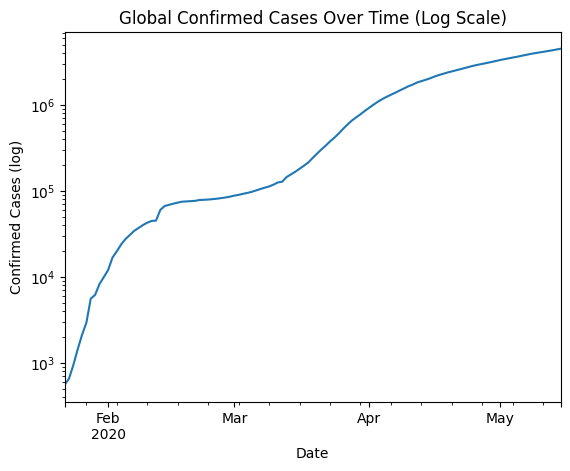

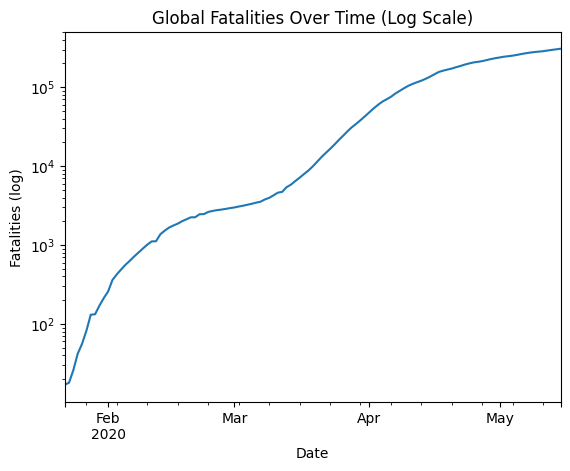

In [12]:
plt.figure()
train.groupby('Date')['ConfirmedCases'].sum().plot()
plt.yscale('log')
plt.title('Global Confirmed Cases Over Time (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases (log)')
plt.show()


plt.figure()
train.groupby('Date')['Fatalities'].sum().plot()
plt.yscale('log')
plt.title('Global Fatalities Over Time (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities (log)')
plt.show()

In [13]:
train_cases = lgb.Dataset(train_set[FEATURES_CASES], label=train_set['log_cases'])
valid_cases = lgb.Dataset(valid_set[FEATURES_CASES], label=valid_set['log_cases'])


model_cases = lgb.train(
    params,
    train_cases,
    valid_sets=[valid_cases],
    num_boost_round=300,
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=100)
    ]
)


# ---- Fatalities Model ----
train_deaths = lgb.Dataset(train_set[FEATURES_DEATHS], label=train_set['log_deaths'])
valid_deaths = lgb.Dataset(valid_set[FEATURES_DEATHS], label=valid_set['log_deaths'])


model_deaths = lgb.train(
    params,
    train_deaths,
    valid_sets=[valid_deaths],
    num_boost_round=300,
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=100)
    ]
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001311 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1744
[LightGBM] [Info] Number of data points in the train set: 21910, number of used features: 8
[LightGBM] [Info] Start training from score 1.717541
Training until validation scores don't improve for 30 rounds
[100]	valid_0's rmse: 0.153122
[200]	valid_0's rmse: 0.123777
[300]	valid_0's rmse: 0.11909
Did not meet early stopping. Best iteration is:
[284]	valid_0's rmse: 0.11801
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1431
[LightGBM] [Info] Number of data points in the train set: 21910, number of used features: 8
[LightGBM] [

In [14]:
full = pd.concat([train, test], sort=False).reset_index(drop=True)
full = full.sort_values(['Region', 'Date']).reset_index(drop=True)

for region in full['Region'].unique():
    region_idx = full[full['Region'] == region].index
    
    for i in range(len(region_idx)):
        idx = region_idx[i]
        
        if pd.isna(full.at[idx, 'ConfirmedCases']):
            
            row = full.loc[idx]
            
            Xc = row[FEATURES_CASES].values.reshape(1, -1)
            Xd = row[FEATURES_DEATHS].values.reshape(1, -1)
            
            pred_cases = np.expm1(model_cases.predict(Xc))[0]
            pred_deaths = np.expm1(model_deaths.predict(Xd))[0]
            

            prev_idx = region_idx[i - 1]
            full.at[idx, 'ConfirmedCases'] = max(pred_cases, full.at[prev_idx, 'ConfirmedCases'])
            full.at[idx, 'Fatalities'] = max(pred_deaths, full.at[prev_idx, 'Fatalities'])
            

            for lag in [1, 3, 7, 14]:
                if i - lag >= 0:
                    lag_idx = region_idx[i - lag]
                    full.at[idx, f'cases_lag_{lag}'] = full.at[lag_idx, 'ConfirmedCases']
                    full.at[idx, f'deaths_lag_{lag}'] = full.at[lag_idx, 'Fatalities']


In [15]:
valid_set = valid_set.copy()
valid_set['pred_log_cases'] = model_cases.predict(valid_set[FEATURES_CASES])
valid_set['pred_log_deaths'] = model_deaths.predict(valid_set[FEATURES_DEATHS])


valid_set['pred_cases'] = np.expm1(valid_set['pred_log_cases'])
valid_set['pred_deaths'] = np.expm1(valid_set['pred_log_deaths'])


# RMSLE calculation
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


cases_rmsle = rmsle(valid_set['ConfirmedCases'], valid_set['pred_cases'])
deaths_rmsle = rmsle(valid_set['Fatalities'], valid_set['pred_deaths'])


print(f'Validation RMSLE - ConfirmedCases: {cases_rmsle:.4f}')
print(f'Validation RMSLE - Fatalities: {deaths_rmsle:.4f}')

Validation RMSLE - ConfirmedCases: 0.1180
Validation RMSLE - Fatalities: 0.1432


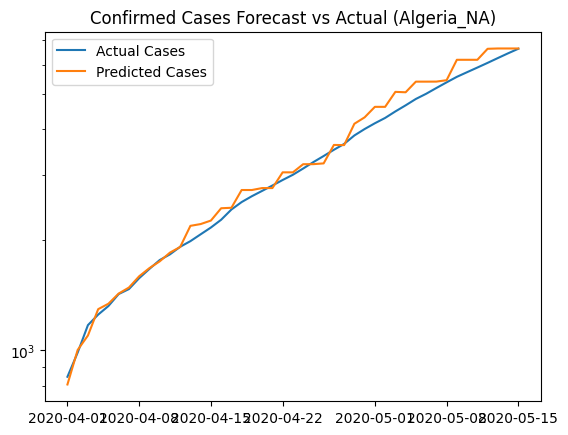

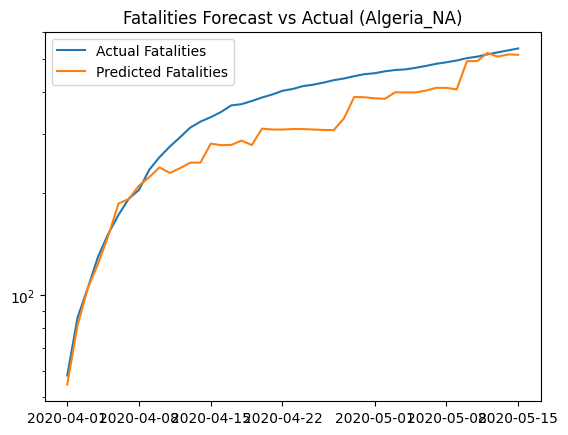

In [16]:
sample_regions = valid_set['Region'].unique()[:3]


for region in sample_regions:
    region_df = valid_set[valid_set['Region'] == region]


plt.figure()
plt.plot(region_df['Date'], region_df['ConfirmedCases'], label='Actual Cases')
plt.plot(region_df['Date'], region_df['pred_cases'], label='Predicted Cases')
plt.yscale('log')
plt.title(f'Confirmed Cases Forecast vs Actual ({region})')
plt.legend()
plt.show()


plt.figure()
plt.plot(region_df['Date'], region_df['Fatalities'], label='Actual Fatalities')
plt.plot(region_df['Date'], region_df['pred_deaths'], label='Predicted Fatalities')
plt.yscale('log')
plt.title(f'Fatalities Forecast vs Actual ({region})')
plt.legend()
plt.show()

In [17]:


region_errors = valid_set.groupby('Region').apply(
    lambda x: rmsle(x['ConfirmedCases'], x['pred_cases'])
).sort_values(ascending=False)


print('Worst 10 Regions by RMSLE (ConfirmedCases):')
print(region_errors.head(10))

Worst 10 Regions by RMSLE (ConfirmedCases):
Region
US_New York          1.009916
Spain_NA             0.791033
Italy_NA             0.756481
Germany_NA           0.549664
France_NA            0.547359
United Kingdom_NA    0.537564
Russia_NA            0.396095
Turkey_NA            0.294720
US_New Jersey        0.291348
Brazil_NA            0.273543
dtype: float64


In [18]:
submission = full.loc[full['ForecastId'].notna(), ['ForecastId', 'ConfirmedCases', 'Fatalities']]
submission['ForecastId'] = submission['ForecastId'].astype(int)


submission.to_csv('submission.csv', index=False)


print('Submission saved as submission.csv')

Submission saved as submission.csv
